# Supply Chain Data Analyst - тестовое задание (Генерация)

Расчёт рекомендуемого количества к заказу (`RecommendedOrder`) по 200 SKU на дату 19.09.2025.

## Настройка

Импорты и настраиваемые параметры, общие для всего ноутбука. Новые импорты дописываю в ячейку ниже, новые параметры - в следующую за ней, а не разбрасываю по коду.

In [1]:
# Path - для удобной и переносимой работы с файловыми путями.
from pathlib import Path

# pandas - основной инструмент для чтения Excel и работы с таблицами.
import pandas as pd

# norm - для z-квантиля нормального распределения в формуле страхового запаса.
from scipy.stats import norm

# matplotlib - для графиков (раздел "Графики").
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# Имена файлов с исходными данными - если файлы переименуют, меняем только здесь.
CANDIDATE_FILE_NAME = "candidate_data.xlsx"
DICTIONARY_FILE_NAME = "data_dictionary.xlsx"

# Дата финального расчёта RecommendedOrder - задана условием задания.
CALCULATION_DATE = pd.Timestamp("2025-09-19")

# Целевой уровень сервиса для доработанной модели (z x std). Не задан в задании явно -
# 95% выбран как разумная отправная точка, чувствительность к этому значению проверяем отдельно.
SERVICE_LEVEL = 0.95

# Альтернативный способ страхового запаса - фиксированное число дней вместо z x std.
# Число не подбиралось через чувствительность (в отличие от SERVICE_LEVEL), взято как
# отправная точка для сравнения методик.
SAFETY_DAYS = 10

# Взвешенное среднее по недавней истории - ещё одна альтернатива наивному среднему по всей
# истории. Ближние RECENT_WINDOW_NEAR_DAYS дней берут вес RECENT_WEIGHT_NEAR, следующие за
# ними (более дальние) RECENT_WINDOW_FAR_DAYS дней - остаток веса (1 - RECENT_WEIGHT_NEAR).
# Как и SAFETY_DAYS, зафиксированы как отправная точка, не подбирались через чувствительность.
RECENT_WINDOW_NEAR_DAYS = 30
RECENT_WINDOW_FAR_DAYS = 30
RECENT_WEIGHT_NEAR = 0.7

## Функции

Здесь собраны все функции, которые дальше используются по ноутбуку - чтобы не искать их по всему файлу, а держать в одном месте. Каждая определена один раз, а проверяется и используется уже там, где впервые нужна.

### `get_protection_period_days` - protection period на произвольную дату

Срок поставки (константа `LEAD_TIME_DAYS`) плюс интервал до следующего заказа из `OrderCalendar`. Нужна и в бэктесте (раздел 2), и в финальном расчёте (раздел 3).

In [3]:
def get_protection_period_days(order_date):
    """Protection period = LeadTimeDays + интервал до следующего заказа из OrderCalendar."""
    # Находим строку календаря для этой даты заказа.
    row = order_calendar_df[order_calendar_df["OrderDate"] == order_date]
    assert len(row) == 1, f"Ожидали одну строку календаря на {order_date}, нашли {len(row)}"
    return int(row["OrderCycleDays"].iloc[0]) + LEAD_TIME_DAYS

### `get_naive_demand_estimate` - наивная оценка спроса (для baseline)

Среднесуточные продажи по каждому SKU, посчитанные только по истории до даты решения, чтобы не подглядывать в будущее. Нужна для baseline-модели - без поправок и без страхового запаса.

In [4]:
def get_naive_demand_estimate(as_of_date):
    """Средний дневной спрос по каждому SKU, посчитанный только по дням строго до as_of_date."""
    # Берём только "прошлое" относительно даты решения — без подглядывания в будущее.
    past_history = history_df[history_df["Date"] < as_of_date]
    return past_history.groupby("SKU")["SalesQty"].mean().rename("mean_daily_sales")

### `get_inventory_position_asof` - позиция запаса на историческую дату

Фактический остаток (с заполненными пропусками) на конец дня перед указанной датой. `InTransit`/`OpenPO` для исторических дат берём за 0, потому что данных о них просто нет (см. допущения бэктеста). Функция возвращает саму позицию и отдельно - число SKU, для которых пришлось поставить fallback 0 (когда нет вообще ни одного наблюдения).

In [5]:
def get_inventory_position_asof(control_date):
    """Стартовая позиция запаса = остаток (с ffill) на конец дня перед control_date. InTransit/OpenPO = 0."""
    prev_day = control_date - pd.Timedelta(days=1)
    day_slice = history_sorted[history_sorted["Date"] == prev_day]
    position = day_slice.set_index("SKU")["stock_filled"].rename("inventory_position")

    # У части SKU нет вообще ни одного наблюдения остатка до этой даты (ffill заполнить нечем) —
    # для них считаем позицию запаса неизвестной, поэтому явно нулевой, а не выдумываем число.
    n_missing = position.isna().sum()
    if n_missing:
        position = position.fillna(0.0)
    return position, n_missing

### `get_actual_demand_over_window` - реализованный спрос за period (для проверки решений)

Сумма фактических продаж по SKU за окно `[control_date, control_date + protection_period_days - 1]` - то есть то, что реально случилось, и с чем бэктест дальше сравнивает решение модели.

In [6]:
def get_actual_demand_over_window(control_date, protection_period_days):
    """Сумма фактических продаж по каждому SKU за [control_date, control_date + protection_period_days - 1]."""
    window_end = control_date + pd.Timedelta(days=protection_period_days - 1)
    window = history_df[(history_df["Date"] >= control_date) & (history_df["Date"] <= window_end)]
    return window.groupby("SKU")["SalesQty"].sum().rename("actual_demand")

### `get_S_with_safety_stock` - S для доработанной модели: дни защиты + страховой запас

`S = средний спрос × protection period + z(Service Level) × std скользящих сумм спроса за такие периоды`. Спрос и его изменчивость считаем по фактическим продажам, без поправок - решение не переписывать историю объяснено в разделе 2.

In [7]:
def get_S_with_safety_stock(as_of_date, protection_period_days, service_level):
    """S = дни защиты (средний спрос x period) + страховой запас (z x std скользящих сумм
    спроса за такие периоды). Спрос берём как есть, по фактическим продажам, без попыток
    угадать недополученный спрос - дефицит меряем через бэктест (shortfall),
    а не переписыванием истории."""
    past_history = history_df[history_df["Date"] < as_of_date].sort_values(["SKU", "Date"])

    # "Дни защиты" - та же логика, что и в baseline.
    mean_daily = past_history.groupby("SKU")["SalesQty"].mean()
    protection_days_component = mean_daily * protection_period_days

    # Страховой запас: эмпирическое std скользящих сумм за period (не daily_std*sqrt(period) -
    # считаем изменчивость сразу на уровне periода, без допущения о независимости дней).
    rolling_sum = (
        past_history.groupby("SKU")["SalesQty"]
        .rolling(protection_period_days)
        .sum()
        .reset_index(level=0)
    )
    std_period = rolling_sum.groupby("SKU")["SalesQty"].std()

    z = norm.ppf(service_level)
    safety_stock = (z * std_period).clip(lower=0)

    S = (
        protection_days_component.reindex(sku_df["SKU"]).fillna(0.0)
        + safety_stock.reindex(sku_df["SKU"]).fillna(0.0)
    )
    return S

### `compute_baseline_decisions` - сборка решений baseline-модели по датам

Прогоняет наивную формулу (`get_naive_demand_estimate` + `get_inventory_position_asof`) по каждой дате из переданного набора и сразу считает `available_to_cover`, `shortfall`, `excess`, `cycle_success` относительно факта (`actual_demand_df`).

In [8]:
def compute_baseline_decisions(dates_df):
    """Решения baseline-модели (среднее по всей истории до даты, без поправок) на переданных датах."""
    rows = []

    # Идём по каждой контрольной дате отдельно - для каждой даты своя история "до" неё
    # и свой protection period, поэтому решение по всем 200 SKU считается заново на каждом шаге цикла.
    for _, cal_row in dates_df.iterrows():
        control_date = cal_row["OrderDate"]
        protection_period_days = int(cal_row["protection_period_days"])

        # Спрос и позиция запаса - только на эту дату, без утечки будущего.
        demand_estimate = get_naive_demand_estimate(control_date)
        inventory_position, _ = get_inventory_position_asof(control_date)

        # Стартуем с одной строки на каждый SKU (как в разделе 1), дальше подтягиваем к ней
        # спрос и позицию запаса через merge - у кого-то из SKU данных может не быть,
        # тогда в колонке будет NaN (это нормально, ниже это не мешает расчёту).
        decision = pd.DataFrame({"SKU": sku_df["SKU"]})
        decision["control_date"] = control_date
        decision["protection_period_days"] = protection_period_days
        decision = decision.merge(demand_estimate, on="SKU", how="left")
        decision = decision.merge(inventory_position, on="SKU", how="left")

        # Сама формула baseline - та же, что и в разделе 1: S = среднее x period,
        # RecommendedOrder = не давать уйти в минус и округлить до целого.
        decision["S"] = decision["mean_daily_sales"] * decision["protection_period_days"]
        gap = decision["S"] - decision["inventory_position"]
        decision["RecommendedOrder"] = gap.round().clip(lower=0).astype(int)
        rows.append(decision)

    # Склеиваем решения по всем датам в одну длинную таблицу (SKU x дата).
    decisions_df = pd.concat(rows, ignore_index=True)

    # Подклеиваем факт - сколько реально продали за тот же период. Без этого нечего
    # будет сравнивать с решением модели.
    decisions_df = decisions_df.merge(actual_demand_df, on=["SKU", "control_date"], how="left")

    # available_to_cover - сколько всего будет на руках (то, что уже есть, плюс заказ).
    # shortfall/excess - на сколько промахнулись мимо факта, каждое не может быть отрицательным.
    # cycle_success - бинарный флаг "обошлось без дефицита вообще" (нужен для Cycle Service Level).
    decisions_df["available_to_cover"] = decisions_df["inventory_position"] + decisions_df["RecommendedOrder"]
    decisions_df["shortfall"] = (decisions_df["actual_demand"] - decisions_df["available_to_cover"]).clip(lower=0)
    decisions_df["excess"] = (decisions_df["available_to_cover"] - decisions_df["actual_demand"]).clip(lower=0)
    decisions_df["cycle_success"] = decisions_df["shortfall"] == 0
    return decisions_df

### `build_decisions` - сборка решений по датам для произвольной функции расчёта `S`

Обобщённая версия `compute_baseline_decisions`: функция расчёта `S` передаётся параметром, поэтому один и тот же код обслуживает и доработанную модель (`get_S_with_safety_stock`), и чувствительность к Service Level - там та же функция просто вызывается с разными `service_level`.

In [9]:
def build_decisions(dates_df, S_func, **S_kwargs):
    """Общая сборка таблицы решений SKU x даты - принимает функцию расчёта S, чтобы не дублировать код
    между baseline и доработанной моделью (отличаются только тем, как считается S)."""
    rows = []
    for _, cal_row in dates_df.iterrows():
        control_date = cal_row["OrderDate"]
        protection_period_days = int(cal_row["protection_period_days"])

        S = S_func(control_date, protection_period_days, **S_kwargs)
        inventory_position, _ = get_inventory_position_asof(control_date)

        decision = pd.DataFrame({"SKU": sku_df["SKU"]})
        decision["control_date"] = control_date
        decision["protection_period_days"] = protection_period_days
        decision = decision.merge(S.rename("S"), on="SKU", how="left")
        decision = decision.merge(inventory_position, on="SKU", how="left")

        gap = decision["S"] - decision["inventory_position"]
        decision["RecommendedOrder"] = gap.round().clip(lower=0).astype(int)
        rows.append(decision)

    decisions_df = pd.concat(rows, ignore_index=True)
    decisions_df = decisions_df.merge(actual_demand_df, on=["SKU", "control_date"], how="left")

    decisions_df["available_to_cover"] = decisions_df["inventory_position"] + decisions_df["RecommendedOrder"]
    decisions_df["shortfall"] = (decisions_df["actual_demand"] - decisions_df["available_to_cover"]).clip(lower=0)
    decisions_df["excess"] = (decisions_df["available_to_cover"] - decisions_df["actual_demand"]).clip(lower=0)
    decisions_df["cycle_success"] = decisions_df["shortfall"] == 0
    return decisions_df

### `compute_metrics` - сводные метрики по таблице решений

Cycle Service Level, Fill Rate, средний и максимальный запас, суммарный дефицит и излишек - одной строкой, из любой таблицы, собранной через `compute_baseline_decisions` или `build_decisions`. Одна и та же функция используется для baseline, доработанной модели и анализа чувствительности.

In [10]:
def compute_metrics(decisions_df, model_name):
    """Сводная строка метрик по таблице решений — переиспользуем для baseline и для доработанной модели."""
    return pd.DataFrame([{
        "model": model_name,
        "cycle_service_level": decisions_df["cycle_success"].mean(),
        "fill_rate": 1 - decisions_df["shortfall"].sum() / decisions_df["actual_demand"].sum(),
        "avg_inventory": decisions_df["available_to_cover"].mean(),
        "max_inventory": decisions_df["available_to_cover"].max(),
        "total_shortfall": decisions_df["shortfall"].sum(),
        "total_excess": decisions_df["excess"].sum(),
    }])

### `get_S_with_fixed_safety_days` - S через фиксированные дни страхового запаса (альтернатива)

Более простая методика для сравнения: `S = средний спрос × (protection_period + SAFETY_DAYS)`, то есть страховой запас = ещё несколько "дней защиты" сверху, без учёта разброса спроса у конкретного SKU. Проще читать и считать, чем z × std, но не различает стабильные и скачкообразные SKU с одинаковым средним - сравнение с `get_S_with_safety_stock` дальше в разделе 2 покажет цену этой простоты.

In [11]:
def get_S_with_fixed_safety_days(as_of_date, protection_period_days, safety_days):
    """S = средний спрос x (protection_period_days + safety_days) - страховой запас
    выражен в днях, а не в единицах товара, и одинаков в днях для всех SKU."""
    past_history = history_df[history_df["Date"] < as_of_date]
    mean_daily = past_history.groupby("SKU")["SalesQty"].mean()
    S = mean_daily * (protection_period_days + safety_days)
    return S.reindex(sku_df["SKU"]).fillna(0.0)

### `get_weighted_recent_demand_estimate` - взвешенное среднее по недавней истории

Альтернатива наивному среднему по всей истории: берём не весь период, а только последние `RECENT_WINDOW_NEAR_DAYS + RECENT_WINDOW_FAR_DAYS` дней, и внутри этого окна даём больше веса более свежим дням. Идея - компенсировать найденную в EDA нестационарность спроса (раздел 1, тренд и сезонность): равновзвешенное по всей истории среднее тянет оценку к более старому и, как выяснилось, более низкому уровню спроса.

In [12]:
def get_weighted_recent_demand_estimate(as_of_date):
    """Средневзвешенный дневной спрос: ближние RECENT_WINDOW_NEAR_DAYS дней с весом
    RECENT_WEIGHT_NEAR, следующие за ними RECENT_WINDOW_FAR_DAYS дней - с весом
    (1 - RECENT_WEIGHT_NEAR). Как и наивная оценка, использует только историю строго
    до as_of_date - без утечки будущего."""
    near_start = as_of_date - pd.Timedelta(days=RECENT_WINDOW_NEAR_DAYS)
    far_start = near_start - pd.Timedelta(days=RECENT_WINDOW_FAR_DAYS)

    near_history = history_df[(history_df["Date"] >= near_start) & (history_df["Date"] < as_of_date)]
    far_history = history_df[(history_df["Date"] >= far_start) & (history_df["Date"] < near_start)]

    # reindex + fillna(0) - на случай если для какого-то SKU в одном из интервалов
    # вообще нет ни одного дня истории (например, интервал уходит раньше начала данных).
    near_mean = near_history.groupby("SKU")["SalesQty"].mean().reindex(sku_df["SKU"]).fillna(0.0)
    far_mean = far_history.groupby("SKU")["SalesQty"].mean().reindex(sku_df["SKU"]).fillna(0.0)

    return (near_mean * RECENT_WEIGHT_NEAR + far_mean * (1 - RECENT_WEIGHT_NEAR)).rename("mean_daily_weighted")

### `get_S_weighted_with_fixed_safety_days` - S через взвешенное среднее + страховой запас в днях

Тот же буфер в днях, что и в `get_S_with_fixed_safety_days`, но вместо наивного среднего по всей истории - взвешенное среднее по недавней истории (см. выше). Сравнение этих двух функций изолирует именно эффект от способа оценки среднего спроса при одном и том же механизме страхового запаса.

In [13]:
def get_S_weighted_with_fixed_safety_days(as_of_date, protection_period_days, safety_days):
    """S = взвешенное среднее (get_weighted_recent_demand_estimate) x (protection_period_days
    + safety_days) - тот же принцип буфера в днях, что в get_S_with_fixed_safety_days,
    но с другой оценкой среднего спроса."""
    mean_daily_weighted = get_weighted_recent_demand_estimate(as_of_date)
    return mean_daily_weighted * (protection_period_days + safety_days)

## Графики

Код построения графиков обычно длиннее самого анализа, поэтому он вынесен сюда - в разделах ниже остаётся только вызов функции и результат, а не десяток строк настройки осей вперемешку с выводами. Цвета моделей зафиксированы один раз (`MODEL_COLORS`) и переиспользуются везде, чтобы один и тот же цвет на разных графиках всегда означал одну и ту же модель.

### Цвета моделей

Фиксированный порядок и цвет для каждой модели - палитра подобрана так, чтобы соседние цвета различались и для людей с цветовой слепотой, не только на глаз.

In [14]:
# Один цвет = одна модель, везде одинаково.
MODEL_COLORS = {
    "Baseline": "#2a78d6",
    f"z x std (SL={SERVICE_LEVEL:.0%})": "#eb6834",
    "Наивное среднее + страховой запас": "#1baf7a",
    f"Взвешенное среднее ({RECENT_WINDOW_NEAR_DAYS}/{RECENT_WINDOW_FAR_DAYS}) + страховой запас": "#7b52ae",
    "Факт (реальные остатки, без модели)": "#eda100",
}

### `plot_sensitivity_metric` - метрика в зависимости от Service Level

Один график - одна метрика (не два масштаба на одних осях). Baseline не имеет своего Service Level, поэтому показан отдельной горизонтальной линией для сравнения, а не точкой на общей шкале.

In [15]:
def plot_sensitivity_metric(sensitivity_df, metric_col, ylabel, title, as_percent=False):
    """График 'метрика vs Service Level' по строкам с именами вида 'SL=NN% (...)',
    плюс горизонтальная линия baseline для сравнения. as_percent=True - для долей
    (Fill Rate, Cycle Service Level), чтобы ось показывала проценты, а не 0.81."""
    # Достаём только строки с SL и парсим сам процент из названия модели.
    sl_rows = sensitivity_df[sensitivity_df["model"].str.contains("SL=")].copy()
    sl_rows["sl_pct"] = sl_rows["model"].str.extract(r"SL=(\d+)%").astype(int)
    sl_rows = sl_rows.sort_values("sl_pct")

    # Baseline не связан с Service Level - берём его значение отдельно, для горизонтальной линии.
    baseline_value = sensitivity_df.loc[
        sensitivity_df["model"].str.contains("Baseline"), metric_col
    ].iloc[0]

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(
        sl_rows["sl_pct"], sl_rows[metric_col],
        marker="o", color="#2a78d6", linewidth=2, markersize=8, label="Доработанная модель",
    )
    ax.axhline(baseline_value, color="#52514e", linestyle="--", linewidth=1.5, label="Baseline")

    ax.set_xlabel("Service Level, %")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(sl_rows["sl_pct"])
    if as_percent:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    # Убираем верхнюю и правую рамку - они не несут информации, только шум.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

### `plot_comparison_bars` - столбчатая диаграмма одной метрики по моделям

Тоже один график - одна метрика. Позволяет исключить модель из конкретного графика (`exclude_models`) - пригодится для Fill Rate у "Факта", который равен 100% тривиально и не сравним по смыслу с остальными.

In [16]:
def plot_comparison_bars(comparison_df, metric_col, ylabel, title, exclude_models=None, as_percent=False):
    """Столбцы одной метрики по моделям, цвет каждой модели берётся из MODEL_COLORS.
    as_percent=True - для долей (Fill Rate, Cycle Service Level), чтобы подписи и ось
    показывали проценты, а не 0.81."""
    df = comparison_df.copy()
    if exclude_models:
        df = df[~df["model"].isin(exclude_models)]

    colors = [MODEL_COLORS.get(m, "#8a8a86") for m in df["model"]]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(df["model"], df[metric_col], color=colors, width=0.6)

    # Подписываем значения прямо над столбцами - удобнее, чем сверять со шкалой на глаз.
    label_fmt = (lambda v: f"{v:.0%}") if as_percent else (lambda v: f"{v:.2f}")
    for bar, value in zip(bars, df[metric_col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(), label_fmt(value),
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if as_percent:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

### `plot_stock_observation_rate` - доля SKU с наблюдаемым остатком по дате

Один график, одна метрика: по оси Y - доля SKU (из 200), для которых в этот день вообще есть значение "Остаток на конец дня" (не пропуск). В норме держится около 100%, провалы в ноль - дни, когда пропуск случился у всех SKU разом.

In [17]:
def plot_stock_observation_rate(observation_rate_by_date):
    """Line chart: доля SKU с наблюдаемым остатком по дате. observation_rate_by_date -
    Series, индекс - Date, значения - доля от 0 до 1."""
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(
        observation_rate_by_date.index, observation_rate_by_date.values,
        color="#2a78d6", linewidth=1,
    )

    ax.set_xlabel("Дата")
    ax.set_ylabel("Доля SKU с остатком")
    ax.set_title("Доля SKU с наблюдаемым остатком по дате")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

### `plot_monthly_demand` - суммарный спрос по месяцам

Один график, одна метрика: суммарные продажи по всем SKU вместе, по месяцам. Нужен только чтобы увидеть тренд и сезонность на глаз, ни в какой расчёт эта функция не идёт.

In [18]:
def plot_monthly_demand(monthly_demand):
    """Bar chart: суммарный спрос по месяцам (все SKU вместе). monthly_demand - Series,
    индекс - pandas Period (месяц), значения - сумма SalesQty за месяц."""
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.bar(monthly_demand.index.astype(str), monthly_demand.values, color="#2a78d6")
    ax.set_xlabel("Месяц")
    ax.set_ylabel("Суммарный спрос, шт.")
    ax.set_title("Суммарный спрос по месяцам (все SKU)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Раздел 1. Baseline

## Пути к данным

Определяем расположение исходных файлов (`candidate_data.xlsx`, `data_dictionary.xlsx`) относительно ноутбука и проверяем, что они на месте.

In [19]:
# Ноутбук лежит в notebooks/, поэтому поднимаемся на один уровень вверх, чтобы попасть в корень проекта.
project_dir = Path.cwd().parent

# Папка с исходными данными — на уровне корня проекта, не внутри notebooks/.
data_dir = project_dir / "data"

# Полные пути к обоим Excel-файлам, собранные из констант в ячейке параметров.
candidate_path = data_dir / CANDIDATE_FILE_NAME
dictionary_path = data_dir / DICTIONARY_FILE_NAME

# Проверяем, что оба файла реально существуют по этим путям, прежде чем пытаться их читать.
# Если assert сработает — сразу понятно, что не так, вместо непонятной ошибки на этапе чтения Excel.
assert candidate_path.exists(), f"Не найден файл: {candidate_path}"
assert dictionary_path.exists(), f"Не найден файл: {dictionary_path}"

print("candidate_data.xlsx найден:", candidate_path)
print("data_dictionary.xlsx найден:", dictionary_path)

candidate_data.xlsx найден: C:\Users\User\Desktop\clode folder\projects_code\тестовое от Генерации\reorder-model\data\candidate_data.xlsx
data_dictionary.xlsx найден: C:\Users\User\Desktop\clode folder\projects_code\тестовое от Генерации\reorder-model\data\data_dictionary.xlsx


## Структура Excel-файлов

Смотрим список листов в обоих файлах, не загружая данные целиком.

In [20]:
# pd.ExcelFile открывает файл и читает его оглавление (список листов),
# но не загружает содержимое листов в память — это быстрее, чем сразу читать все данные.
candidate_excel = pd.ExcelFile(candidate_path)
dictionary_excel = pd.ExcelFile(dictionary_path)

print("Листы в candidate_data.xlsx:", candidate_excel.sheet_names)
print("Листы в data_dictionary.xlsx:", dictionary_excel.sheet_names)

Листы в candidate_data.xlsx: ['SKU', 'DailyHistory', 'OpenSupply', 'OrderCalendar']
Листы в data_dictionary.xlsx: ['Поля', 'Условия']


### Словарь полей

Читаем лист "Поля" - там описание всех колонок в данных, дальше это поможет их правильно интерпретировать.

In [21]:
# Читаем лист "Поля" целиком — он небольшой, это справочная таблица, а не данные для расчёта.
fields_df = pd.read_excel(dictionary_path, sheet_name="Поля")

# pd.set_option, чтобы длинные текстовые описания не обрезались "...".
pd.set_option("display.max_colwidth", None)

fields_df

,Лист,Поле,Единицы,Определение
0,SKU,SKU,Текст,Идентификатор позиции активного ассортимента. Один SKU — одна строка.
1,SKU,CurrentStock,Шт.,"Текущий остаток на дату расчёта 19.09.2025, до размещения заказа."
2,SKU,InTransit,Шт.,"Отгруженное, ещё не полученное количество. Сумма строк OpenSupply со Status = InTransit."
3,SKU,OpenPO,Шт.,"Размещённое, ещё не отгруженное количество. Сумма строк OpenSupply со Status = OpenPO."
4,SKU,LeadTimeDays,Календарные дни,Учебный срок нового заказа — 10 дней. Для уже размещённых поставок используйте ExpectedReceiptDate.
5,DailyHistory,Date,Дата,День наблюдения. Одна строка на SKU и календарный день.
6,DailyHistory,SKU,Текст,"Идентификатор, связанный с листом SKU."
7,DailyHistory,SalesQty,Шт.,Фактически выполненные продажи за указанный день. Возвраты не вычитаются.
8,DailyHistory,Остаток на конец дня,Шт.,Остаток на конец указанного дня. Пустая ячейка означает отсутствие наблюдения.
9,OpenSupply,PO_ID,Текст,Обезличенный идентификатор отдельной учебной поставки.


### Условия задачи

Читаем лист "Условия" - явные допущения и параметры, которые задал заказчик (срок поставки, календарь и так далее).

In [22]:
conditions_df = pd.read_excel(dictionary_path, sheet_name="Условия")
conditions_df

,Параметр,Значение
0,Дата расчёта,"19.09.2025, до размещения заказа"
1,История,19.06.2024–18.09.2025; 457 дней; 200 SKU
2,Гранулярность,SKU × календарный день
3,Конец дня,Столбец «Остаток на конец дня» относится к дню Date.
4,Единицы,Все количества — штуки; внутренние перемещения возможны поштучно.
5,Отсутствующие значения,Пустой остаток — наблюдения нет. Все SKU активного ассортимента остаются в итоговом расчёте.
6,История продаж,Фактически выполненные продажи. Исторического журнала неудовлетворённого спроса нет.
7,Учебные условия,"LeadTimeDays, календарь заказов и строки OpenSupply заданы для задания; это не реальные параметры компании."
8,Поставки,InTransit и OpenPO — разные состояния. Сводные количества SKU и строки OpenSupply описывают один набор поставок.
9,Исторические поставки,OpenSupply — снимок только на дату расчёта. Для backtesting требуется явно задать начальное состояние и правила моделирования.


### Лист SKU

Загружаем таблицу активного ассортимента: текущие остатки, открытые поставки, срок поставки.

In [23]:
# Лист SKU — одна строка на позицию активного ассортимента (ожидаем 200 строк).
sku_df = pd.read_excel(candidate_path, sheet_name="SKU")

print("Форма таблицы (строки, колонки):", sku_df.shape)
print("Колонки:", list(sku_df.columns))
sku_df.head()

Форма таблицы (строки, колонки): (200, 5)
Колонки: ['SKU', 'CurrentStock', 'InTransit', 'OpenPO', 'LeadTimeDays']


,SKU,CurrentStock,InTransit,OpenPO,LeadTimeDays
0,TEST-0001,0,0,0,10
1,TEST-0002,3,0,1,10
2,TEST-0003,19,4,7,10
3,TEST-0004,0,0,0,10
4,TEST-0005,18,2,0,10


### Лист DailyHistory

Загружаем дневную историю продаж и остатков - это самая большая таблица (200 SKU × 457 дней).

In [24]:
history_df = pd.read_excel(candidate_path, sheet_name="DailyHistory")

print("Форма таблицы (строки, колонки):", history_df.shape)
print("Колонки:", list(history_df.columns))
print("Диапазон дат:", history_df["Date"].min(), "—", history_df["Date"].max())
history_df.head()

Форма таблицы (строки, колонки): (91400, 4)
Колонки: ['Date', 'SKU', 'SalesQty', 'Остаток на конец дня']
Диапазон дат: 2024-06-19 00:00:00 — 2025-09-18 00:00:00


,Date,SKU,SalesQty,Остаток на конец дня
0,2024-06-19,TEST-0001,0,2.0
1,2024-06-20,TEST-0001,0,2.0
2,2024-06-21,TEST-0001,0,2.0
3,2024-06-22,TEST-0001,0,2.0
4,2024-06-23,TEST-0001,0,2.0


### Лист OpenSupply

Загружаем список уже размещённых поставок (InTransit/OpenPO) - снимок на дату расчёта.

In [25]:
open_supply_df = pd.read_excel(candidate_path, sheet_name="OpenSupply")

print("Форма таблицы (строки, колонки):", open_supply_df.shape)
print("Колонки:", list(open_supply_df.columns))
open_supply_df.head()

Форма таблицы (строки, колонки): (199, 6)
Колонки: ['PO_ID', 'SKU', 'Qty', 'Status', 'PlacedDate', 'ExpectedReceiptDate']


,PO_ID,SKU,Qty,Status,PlacedDate,ExpectedReceiptDate
0,PO-0002-1,TEST-0002,1,OpenPO,2025-09-15,2025-09-24
1,PO-0003-1,TEST-0003,4,InTransit,2025-09-14,2025-09-27
2,PO-0003-2,TEST-0003,7,OpenPO,2025-09-13,2025-10-04
3,PO-0005-1,TEST-0005,2,InTransit,2025-09-12,2025-10-03
4,PO-0006-1,TEST-0006,1,OpenPO,2025-09-11,2025-10-06


### Лист OrderCalendar

Загружаем календарь размещения заказов, он понадобится для расчёта protection period.

In [26]:
order_calendar_df = pd.read_excel(candidate_path, sheet_name="OrderCalendar")

print("Форма таблицы (строки, колонки):", order_calendar_df.shape)
print("Колонки:", list(order_calendar_df.columns))
order_calendar_df.head()

Форма таблицы (строки, колонки): (157, 3)
Колонки: ['OrderDate', 'NextOrderDate', 'OrderCycleDays']


,OrderDate,NextOrderDate,OrderCycleDays
0,2024-06-19,2024-06-21,2
1,2024-06-21,2024-06-26,5
2,2024-06-26,2024-06-28,2
3,2024-06-28,2024-07-03,5
4,2024-07-03,2024-07-05,2


## Полнота календарной истории

Проверяем, что в `DailyHistory` ровно одна строка на каждую пару SKU-день, без пропущенных дней и без дублей.

In [27]:
# Считаем число строк, число уникальных пар SKU+Date и ожидаемое число (SKU x дни).
n_rows = len(history_df)
n_unique_pairs = history_df[["SKU", "Date"]].drop_duplicates().shape[0]
n_expected = sku_df["SKU"].nunique() * history_df["Date"].nunique()

print("Строк в DailyHistory:", n_rows)
print("Уникальных пар SKU+Date:", n_unique_pairs)
print("Ожидается (SKU x дни):", n_expected)
print("Дубликатов пар SKU+Date:", n_rows - n_unique_pairs)

Строк в DailyHistory: 91400
Уникальных пар SKU+Date: 91400
Ожидается (SKU x дни): 91400
Дубликатов пар SKU+Date: 0


## Пропуски в данных

Считаем долю пропусков в `SalesQty` и в «Остаток на конец дня» (по словарю полей пустой остаток значит «нет наблюдения», а не ноль).

In [28]:
missing_sales = history_df["SalesQty"].isna().sum()
missing_stock = history_df["Остаток на конец дня"].isna().sum()

print(f"Пропуски в SalesQty: {missing_sales} ({missing_sales / n_rows:.2%})")
print(f"Пропуски в 'Остаток на конец дня': {missing_stock} ({missing_stock / n_rows:.2%})")

Пропуски в SalesQty: 0 (0.00%)
Пропуски в 'Остаток на конец дня': 1489 (1.63%)


## Пропуски остатка по датам

Общая доля пропусков (1,63%) уже посчитана выше, но интересно, как они распределены по времени - равномерно размазаны или сконцентрированы в конкретные дни.

Дат с пропуском остатка у всех 200 SKU разом: 2
['2025-06-01', '2025-06-29']


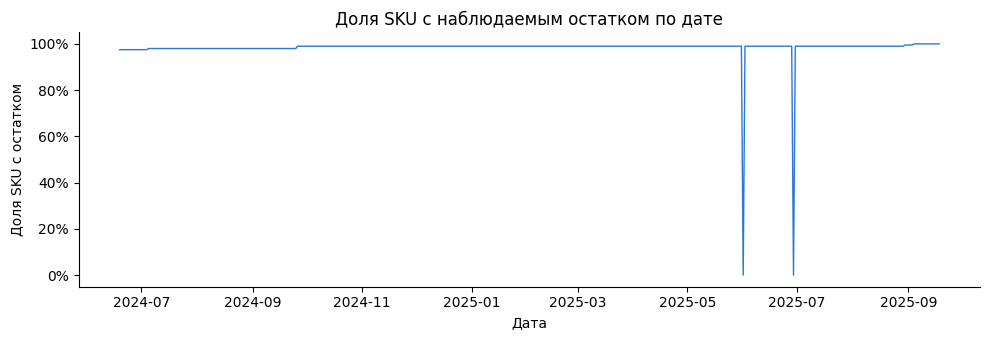

In [29]:
# Для каждой даты считаем долю SKU (из 200), у которых остаток в этот день наблюдается.
missing_by_date = history_df.groupby("Date")["Остаток на конец дня"].apply(lambda s: s.isna().sum())
observation_rate_by_date = 1 - missing_by_date / 200

# Даты, где пропуск случился абсолютно у всех 200 SKU разом - это не "у каждого свой пропуск",
# а системный провал наблюдения на уровне всего дня.
fully_missing_dates = missing_by_date[missing_by_date == 200]

print("Дат с пропуском остатка у всех 200 SKU разом:", len(fully_missing_dates))
print(fully_missing_dates.index.strftime("%Y-%m-%d").tolist())

plot_stock_observation_rate(observation_rate_by_date)

### Выводы и наблюдения

- Два дня - **01.06.2025 и 29.06.2025** - остаток не наблюдается вообще ни у одного из 200 SKU. На графике это видно как два чётких провала в ноль на фоне ровной линии около 100%.
- Это не "у каждого SKU свой случайный пропуск" (как остальные ~1,6% пропусков, размазанные по разным датам и SKU) - а системный сбой наблюдения на уровне всего дня целиком, скорее всего технический (не собрали/не выгрузили данные), а не что-то про сам товар.
- Как и с остальными пропусками остатка: трактуем как "нет наблюдения", а не как нулевой остаток - `SalesQty` в эти дни не пуст (полностью заполнен, EDA выше), так что на оценку спроса эти два дня не влияют.

## Активность продаж по SKU

Для каждого SKU считаем долю дней с продажами и суммарный спрос: хочу понять, насколько распространён прерывистый спрос и есть ли SKU совсем без истории продаж.

In [30]:
# Группируем по SKU и считаем базовые показатели активности спроса.
sku_activity = history_df.groupby("SKU").agg(
    days_total=("SalesQty", "size"),
    days_with_sales=("SalesQty", lambda s: (s > 0).sum()),
    total_sales=("SalesQty", "sum"),
    mean_daily_sales=("SalesQty", "mean"),
).reset_index()

# Доля дней с продажами — ключевой индикатор прерывистости спроса.
sku_activity["share_days_with_sales"] = sku_activity["days_with_sales"] / sku_activity["days_total"]

print("SKU без единой продажи за всю историю:", (sku_activity["total_sales"] == 0).sum())
print("Медианная доля дней с продажами по SKU:", round(sku_activity["share_days_with_sales"].median(), 4))
print("SKU с долей дней с продажами < 10%:", (sku_activity["share_days_with_sales"] < 0.10).sum())

sku_activity.sort_values("total_sales").head(10)

SKU без единой продажи за всю историю: 18
Медианная доля дней с продажами по SKU: 0.0098
SKU с долей дней с продажами < 10%: 170


,SKU,days_total,days_with_sales,total_sales,mean_daily_sales,share_days_with_sales
7,TEST-0008,457,0,0,0.0,0.0
11,TEST-0012,457,0,0,0.0,0.0
29,TEST-0030,457,0,0,0.0,0.0
18,TEST-0019,457,0,0,0.0,0.0
49,TEST-0050,457,0,0,0.0,0.0
59,TEST-0060,457,0,0,0.0,0.0
43,TEST-0044,457,0,0,0.0,0.0
34,TEST-0035,457,0,0,0.0,0.0
60,TEST-0061,457,0,0,0.0,0.0
77,TEST-0078,457,0,0,0.0,0.0


## Тренд и сезонность спроса

Модель везде считает средний спрос и его разброс с равным весом по всей доступной истории (457 дней). Если внутри неё есть выраженный тренд или сезонность, такая оценка будет смещена относительно текущего уровня спроса. Проверяю, есть ли такой эффект вообще - по месяцам и по первой/второй половине истории.

**Важно: это только описательная проверка, а не поправка к модели.** Если превратить найденную сезонность в коэффициент и подмешать его в оценку `S` для дат бэктеста - это была бы утечка данных: сезонный профиль здесь посчитан по всей истории целиком, а значит для любой даты бэктеста раньше конца истории он неявно "знает" про месяцы, которые для этой даты решения ещё не наступили. Поэтому дальше в ноутбуке сезонность нигде не используется как вход в расчёт `S` - только показывается здесь как факт про данные и попадает в список ограничений.

Среднесуточный спрос: первая половина истории = 70.1 шт/день, вторая половина = 79.6 шт/день (+14%)


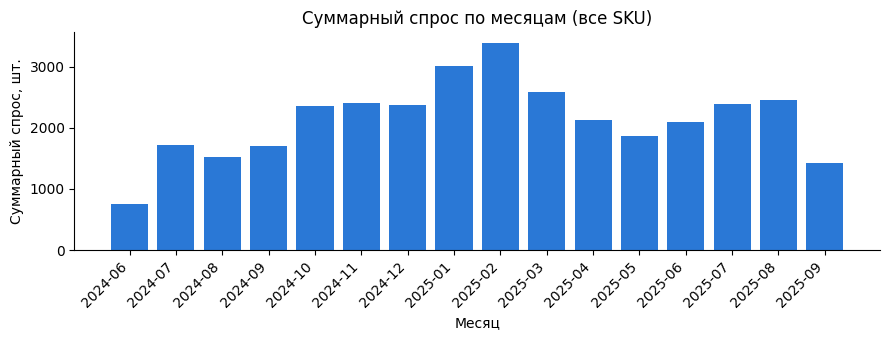

In [31]:
# Суммарный спрос по месяцам - для наглядности на графике.
monthly_demand = history_df.groupby(history_df["Date"].dt.to_period("M"))["SalesQty"].sum()

# Грубая проверка тренда: делим историю пополам по времени и сравниваем среднесуточный спрос.
mid_date = history_df["Date"].min() + (history_df["Date"].max() - history_df["Date"].min()) / 2
first_half = history_df[history_df["Date"] < mid_date]
second_half = history_df[history_df["Date"] >= mid_date]
first_half_rate = first_half["SalesQty"].sum() / first_half["Date"].nunique()
second_half_rate = second_half["SalesQty"].sum() / second_half["Date"].nunique()

print(
    f"Среднесуточный спрос: первая половина истории = {first_half_rate:.1f} шт/день, "
    f"вторая половина = {second_half_rate:.1f} шт/день ({(second_half_rate / first_half_rate - 1):+.0%})"
)

plot_monthly_demand(monthly_demand)

## Проверка на очевидные аномалии

Ищем отрицательные значения продаж/остатков и другие явно некорректные данные.

In [32]:
print("Отрицательные значения SalesQty:", (history_df["SalesQty"] < 0).sum())
print("Отрицательные значения остатка:", (history_df["Остаток на конец дня"] < 0).sum())
print("Максимальная продажа за день:", history_df["SalesQty"].max())
print("Максимальный остаток на конец дня:", history_df["Остаток на конец дня"].max())

Отрицательные значения SalesQty: 0
Отрицательные значения остатка: 0
Максимальная продажа за день: 150
Максимальный остаток на конец дня: 559.0


### Выбросы в продажах

Отдельно ищу разовые продажи, сильно превышающие типичный уровень конкретного SKU - для запчастей это может быть как обычный разовый оптовый заказ, так и ошибка ввода, и по одним данным их не различить. Правило: значение выше `Q3 + 3×IQR` среди ненулевых продаж этого же SKU - считаю внутри каждого SKU отдельно, а не по всему датасету сразу, иначе "типичный уровень" тихого и объёмного SKU перепутаются между собой.

In [33]:
nonzero_sales = history_df[history_df["SalesQty"] > 0]


def count_iqr_outliers(sales):
    """Число значений выше Q3 + 3*IQR внутри одной серии (один SKU)."""
    if len(sales) < 4:
        return 0
    q1, q3 = sales.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 3 * iqr if iqr > 0 else q3
    return int((sales > upper).sum())


outlier_counts_by_sku = nonzero_sales.groupby("SKU")["SalesQty"].apply(count_iqr_outliers)

print("Строк-выбросов (> Q3 + 3xIQR внутри своего SKU):", outlier_counts_by_sku.sum(), "из", len(nonzero_sales))
print("SKU, затронутых хотя бы одним выбросом:", (outlier_counts_by_sku > 0).sum(), "из", sku_df["SKU"].nunique())

Строк-выбросов (> Q3 + 3xIQR внутри своего SKU): 105 из 4225
SKU, затронутых хотя бы одним выбросом: 38 из 200


### Расхождение CurrentStock и последнего известного остатка истории

`CurrentStock` в листе SKU - это остаток на дату расчёта (19.09.2025), а последняя дата в `DailyHistory` - 18.09.2025. Между ними физически могло что-то произойти (продажа, поставка, ручная корректировка), так что небольшое расхождение ожидаемо. Проверяю, у скольких SKU оно есть и насколько большое - просто чтобы не пропустить что-то более серьёзное, чем однодневный сдвиг.

In [34]:
# Последний известный остаток по каждому SKU (пропуски внутри истории пропускаем, а не заполняем -
# здесь важна именно последняя РЕАЛЬНО наблюдённая точка, а не сегодняшнее приближение).
last_known_stock_by_sku = (
    history_df.dropna(subset=["Остаток на конец дня"])
    .sort_values(["SKU", "Date"])
    .groupby("SKU")["Остаток на конец дня"]
    .last()
)

stock_gap = (
    sku_df.set_index("SKU")["CurrentStock"] - last_known_stock_by_sku.reindex(sku_df["SKU"])
).dropna()

print(
    "SKU, где CurrentStock (19.09) отличается от последнего известного остатка истории:",
    (stock_gap != 0).sum(), "из", len(stock_gap),
)
print("Максимальное расхождение (по модулю):", stock_gap.abs().max(), "шт.")
stock_gap[stock_gap != 0].sort_values().head(10)

SKU, где CurrentStock (19.09) отличается от последнего известного остатка истории: 16 из 200
Максимальное расхождение (по модулю): 47.0 шт.


SKU
TEST-0036   -47.0
TEST-0164   -34.0
TEST-0107   -28.0
TEST-0043   -23.0
TEST-0015   -18.0
TEST-0063   -13.0
TEST-0025   -12.0
TEST-0118   -11.0
TEST-0190    -8.0
TEST-0088    -5.0
dtype: float64

### Выводы и наблюдения

- Календарь наблюдений полный: 91 400 строк, дублей нет, пропущенных дней тоже нет.
- `SalesQty` заполнен без единого пропуска, так что для наивной оценки спроса дополнительная очистка не нужна.
- В «Остаток на конец дня» 1,63% пропусков (это «нет наблюдения», а не ноль). Для baseline это не критично, спрос всё равно оцениваем по `SalesQty`, но пригодится для бэктеста в разделе 2, где понадобится стартовое состояние запасов.
- Спрос по большинству SKU сильно прерывистый: медианная доля дней с продажами - **0,98%**, у 170 из 200 SKU (85%) доля дней с продажами меньше 10%. Наивное среднее по всей истории это переживёт, но оценка получится грубой - это ожидаемая точка для доработки в разделе 2, а не проблема, которую нужно решать прямо сейчас.
- **18 SKU (9%) вообще не имеют ни одной продажи за все 457 дней.** Для них наивная оценка спроса даст 0, и им понадобится явный fallback и пометка в итоговой таблице - по условию задания такие позиции нельзя просто пропустить.
- Отрицательных значений в продажах и остатках нет, максимум продаж за день - 150 шт., максимум остатка - 559 шт.
- **Спрос не стационарен во времени.** Среднесуточный спрос во второй половине истории заметно выше, чем в первой, и виден сезонный пик в зимние месяцы. Модель везде взвешивает историю поровну, поэтому это источник смещения оценки, а не что-то, что она учитывает - это ограничение модели, а не проблема данных. Специально не превращаю эту находку в поправку к формуле спроса - это было бы утечкой данных в бэктест (подробнее - в блоке про сезонность выше).
- **Выбросы в продажах есть, но не вырезаю.** Разовые продажи, кратно превышающие типичный уровень своего SKU, найдены у части ассортимента (правило Q3 + 3×IQR внутри SKU). Без дополнительного знания бизнеса нельзя отличить разовый оптовый заказ от ошибки ввода, а модель раздела 2 использует квантиль/страховой запас с учётом разброса, а не голое среднее - то есть редкие крупные значения и так учитываются защитой запаса, а не сглаживаются заранее.
- **CurrentStock (19.09) у части SKU отличается от последнего известного остатка истории (18.09).** Ожидаемо - между этими датами есть однодневный слепой промежуток, где что-то могло измениться, а `CurrentStock` как более свежий источник и используется дальше в финальном расчёте (раздел 3).

**Отдельный шаг «приведение данных в порядок» пропускаю** - для baseline он оказался бы пустым: `SalesQty` без пропусков, дублей и отрицательных значений, а найденные особенности (пропуски остатка, SKU без истории, нестационарность спроса, выбросы, расхождение CurrentStock) - это не грязные данные, а случаи, которые нужно явно учесть в логике модели или отметить как ограничение, а не почистить заранее.

## Protection period - интервал до следующего заказа

Дата расчёта - это дата размещения заказа. Заказанное сегодня количество должно закрыть спрос не до следующей даты заказа, а до прихода *следующей за ней* поставки, поэтому берём интервал до следующего заказа из `OrderCalendar`, а не хардкодим его.

In [35]:
# Находим в календаре строку, где OrderDate — это наша дата расчёта.
calc_date_row = order_calendar_df[order_calendar_df["OrderDate"] == CALCULATION_DATE]

# Ожидаем ровно одну строку — на каждую разрешённую дату заказа календарь даёт один интервал до следующей.
assert len(calc_date_row) == 1, f"Ожидали одну строку календаря на {CALCULATION_DATE.date()}, нашли {len(calc_date_row)}"

# OrderCycleDays — сколько дней пройдёт до следующей возможности заказать (2 после среды, 5 после пятницы).
order_cycle_days = int(calc_date_row["OrderCycleDays"].iloc[0])
next_order_date = calc_date_row["NextOrderDate"].iloc[0]

print("Дата расчёта:", CALCULATION_DATE.date())
print("Следующая дата заказа:", next_order_date.date())
print("Интервал до следующего заказа (OrderCycleDays):", order_cycle_days, "дней")

Дата расчёта: 2025-09-19
Следующая дата заказа: 2025-09-24
Интервал до следующего заказа (OrderCycleDays): 5 дней


## Protection period по каждому SKU

`LeadTimeDays` - колонка в `SKU`, а не глобальная константа, поэтому protection period считаю на уровне SKU. По условию задания срок поставки у всех одинаковый, но это совпадение, и код на него специально не опирается.

In [36]:
# Начинаем сборку рабочей таблицы baseline_df с копии SKU, чтобы не менять исходный sku_df.
baseline_df = sku_df.copy()

# Protection period = срок поставки нового заказа (LeadTimeDays) + интервал до следующего заказа.
baseline_df["protection_period_days"] = baseline_df["LeadTimeDays"] + order_cycle_days

print("Уникальные значения LeadTimeDays:", sorted(baseline_df["LeadTimeDays"].unique()))
print("Уникальные значения protection_period_days:", sorted(baseline_df["protection_period_days"].unique()))

Уникальные значения LeadTimeDays: [np.int64(10)]
Уникальные значения protection_period_days: [np.int64(15)]


## Наивная оценка спроса

Берём среднесуточный спрос по всей истории - он уже посчитан в `sku_activity` (активность продаж по SKU) как `mean_daily_sales`, среднее по всем дням, включая дни без продаж, и это корректная оценка интенсивности спроса. Умножаем на protection period.

In [37]:
# Подтягиваем среднесуточный спрос по SKU из таблицы активности (EDA).
baseline_df = baseline_df.merge(
    sku_activity[["SKU", "mean_daily_sales"]],
    on="SKU",
    how="left",
)

# Ожидаемый спрос за protection period — простое произведение, без поправок на дефицит.
baseline_df["demand_over_protection"] = baseline_df["mean_daily_sales"] * baseline_df["protection_period_days"]

print("SKU с нулевым ожидаемым спросом за protection period:", (baseline_df["demand_over_protection"] == 0).sum())
baseline_df[["SKU", "mean_daily_sales", "protection_period_days", "demand_over_protection"]].describe()

SKU с нулевым ожидаемым спросом за protection period: 18


,mean_daily_sales,protection_period_days,demand_over_protection
count,200.000000,200.0,200.000000
mean,0.374333,15.0,5.614989
std,1.131424,0.0,16.971359
min,0.000000,15.0,0.000000
25%,0.006565,15.0,0.098468
50%,0.031729,15.0,0.475930
75%,0.234683,15.0,3.520241
max,10.557987,15.0,158.369803


## Order-up-to level (S) и Inventory Position - baseline

Baseline сознательно простой: без страхового запаса и без фильтрации поставок по горизонту прихода. Это не забыто, а сделано намеренно - baseline должен быть наивной точкой сравнения для более аккуратной модели в разделе 2, а не черновиком финальной модели.

- `S = demand_over_protection` (без safety stock).
- `InventoryPosition = CurrentStock + InTransit + OpenPO` (без фильтра по дате прихода).

In [38]:
# Order-up-to level для baseline — без страхового запаса, чистое ожидание спроса.
baseline_df["S_baseline"] = baseline_df["demand_over_protection"]

# Позиция запаса — текущий остаток плюс всё, что уже в пути или заказано.
baseline_df["inventory_position"] = (
    baseline_df["CurrentStock"] + baseline_df["InTransit"] + baseline_df["OpenPO"]
)

baseline_df[["SKU", "S_baseline", "inventory_position"]].describe()

,S_baseline,inventory_position
count,200.000000,200.000000
mean,5.614989,15.515000
std,16.971359,33.771621
min,0.000000,0.000000
25%,0.098468,2.000000
50%,0.475930,4.000000
75%,3.520241,13.000000
max,158.369803,236.000000


## RecommendedOrder - baseline

`RecommendedOrder = max(0, round(S - InventoryPosition))` - целое и неотрицательное, как требует задание.

In [39]:
# round() до целого, затем max(0, ...) — неотрицательное количество.
gap = baseline_df["S_baseline"] - baseline_df["inventory_position"]
baseline_df["RecommendedOrder_baseline"] = gap.round().clip(lower=0).astype(int)

print("Строк в baseline_df:", len(baseline_df))
print("Все 200 SKU на месте:", set(baseline_df["SKU"]) == set(sku_df["SKU"]))
print("Суммарный объём заказа по baseline:", baseline_df["RecommendedOrder_baseline"].sum(), "шт.")
print("SKU с RecommendedOrder > 0:", (baseline_df["RecommendedOrder_baseline"] > 0).sum())

baseline_df[["SKU", "S_baseline", "inventory_position", "RecommendedOrder_baseline"]].sort_values(
    "RecommendedOrder_baseline", ascending=False
).head(10)

Строк в baseline_df: 200
Все 200 SKU на месте: True
Суммарный объём заказа по baseline: 97 шт.
SKU с RecommendedOrder > 0: 18


,SKU,S_baseline,inventory_position,RecommendedOrder_baseline
135,TEST-0136,22.910284,0,23
24,TEST-0025,96.695842,85,12
48,TEST-0049,9.518600,0,10
33,TEST-0034,7.483589,0,7
81,TEST-0082,15.689278,9,7
108,TEST-0109,6.630197,0,7
51,TEST-0052,7.385120,0,7
129,TEST-0130,7.582057,3,5
162,TEST-0163,4.135667,0,4
90,TEST-0091,3.971554,0,4


### Выводы и наблюдения

- Protection period на 19.09.2025 = 10 (лид-тайм) + 5 (интервал до следующего заказа из календаря) = **15 дней**, одинаков для всех SKU (`LeadTimeDays` в данных везде равен 10, но код это не предполагает заранее, а вычисляет сам).
- Baseline-формула прогнана на всех 200 SKU без ошибок, `RecommendedOrder` у всех строк целое и неотрицательное.
- Суммарный объём заказа по baseline - **97 шт.**, но только у **18 из 200 SKU** (9%) `RecommendedOrder` получился больше нуля. Это ожидаемо, не баг: без страхового запаса заказ появляется только там, где текущей позиции запаса не хватает даже на голый средний спрос за 15 дней, а для позиций с прерывистым спросом это редкий случай.
- 18 SKU без истории продаж (найдены в EDA) получили `RecommendedOrder_baseline = 0` - формула ведёт себя корректно (нулевой спрос → нулевая рекомендация), но по условию задания для таких позиций нужна явная пометка в итоговой таблице. Саму формулу это не меняет, займусь этим в разделе 3, там же, где собирается финальная таблица.
- Baseline намеренно **не включает** страховой запас, поправку на дефицит (censored demand) и фильтрацию поставок по горизонту прихода. Это не недоработка, а точка сравнения: та же формула (`S_baseline`, `inventory_position`) без изменений пойдёт как baseline при сравнении с доработанной моделью в разделе 2.

# Раздел 2. Бэктесты и отладка

## Выбор контрольных дат

Берём даты заказа из `OrderCalendar`, кроме самой даты расчёта 19.09.2025 - она зарезервирована под финальный расчёт в разделе 3. Дата валидна, если после неё в истории хватает данных минимум на весь её protection period вперёд, иначе не с чем будет сравнить рекомендацию: не увидим реальный спрос за этот период. Из валидных берём 8 последних - перебирать все 156 не нужно, для проверки модели этого достаточно.

In [40]:
# На шаге 14 подтвердили, что LeadTimeDays одинаков у всех SKU — фиксируем это явной проверкой
# (а не молчаливым предположением) и используем как скаляр для расчётов на уровне календаря.
assert sku_df["LeadTimeDays"].nunique() == 1, "LeadTimeDays неоднороден - protection period нельзя считать на уровне календаря одним числом"
LEAD_TIME_DAYS = int(sku_df["LeadTimeDays"].iloc[0])

In [41]:
# Последний доступный день фактической истории — дальше него сравнивать не с чем.
last_history_date = history_df["Date"].max()

# protection period одинаков для всех SKU (LeadTimeDays константа), поэтому считаем его на уровне календаря,
# а не на уровне SKU, как в baseline — тут это одно число на дату, а не на строку.
calendar_check = order_calendar_df.copy()
calendar_check["protection_period_days"] = calendar_check["OrderCycleDays"] + LEAD_TIME_DAYS
calendar_check["last_covered_date"] = calendar_check["OrderDate"] + pd.to_timedelta(
    calendar_check["protection_period_days"], unit="D"
)

# Валидные даты: не сама дата расчёта, и после них в истории есть данные на весь protection period.
is_not_calc_date = calendar_check["OrderDate"] != CALCULATION_DATE
has_enough_future_history = calendar_check["last_covered_date"] <= last_history_date
valid_control_dates = calendar_check[is_not_calc_date & has_enough_future_history]

# Берём 8 последних валидных дат — они ближе всего по времени к дате расчёта.
N_CONTROL_DATES = 8
control_dates_df = valid_control_dates.sort_values("OrderDate").tail(N_CONTROL_DATES).reset_index(drop=True)

print("Всего дат в календаре:", len(order_calendar_df))
print("Валидных дат (хватает будущей истории):", len(valid_control_dates))
print("Выбрано контрольных дат:", len(control_dates_df))
control_dates_df[["OrderDate", "OrderCycleDays", "protection_period_days", "last_covered_date"]]

Всего дат в календаре: 157
Валидных дат (хватает будущей истории): 127
Выбрано контрольных дат: 8


,OrderDate,OrderCycleDays,protection_period_days,last_covered_date
0,2025-08-08,5,15,2025-08-23
1,2025-08-13,2,12,2025-08-25
2,2025-08-15,5,15,2025-08-30
3,2025-08-20,2,12,2025-09-01
4,2025-08-22,5,15,2025-09-06
5,2025-08-27,2,12,2025-09-08
6,2025-08-29,5,15,2025-09-13
7,2025-09-03,2,12,2025-09-15


## Разделение на подбор параметров и проверку

Чтобы не подбирать Service Level и не проверять итоговый результат на одних и тех же данных, делим 8 контрольных дат по времени: более ранние идут на подбор параметра (чувствительность к Service Level ниже), более поздние, ближе к дате расчёта, - на итоговую проверку и сравнение с baseline. Разделение не идеальное, дат маловато, но оно даёт честную проверку вместо подбора и оценки на одном и том же наборе.

In [42]:
# Более ранние 5 дат - подбор параметра (TUNE), более поздние 3 - независимая проверка (TEST).
tune_dates_df = control_dates_df.iloc[:5].reset_index(drop=True)
test_dates_df = control_dates_df.iloc[5:].reset_index(drop=True)

print("TUNE (подбор SL):", tune_dates_df["OrderDate"].dt.date.tolist())
print("TEST (проверка/сравнение с baseline):", test_dates_df["OrderDate"].dt.date.tolist())

TUNE (подбор SL): [datetime.date(2025, 8, 8), datetime.date(2025, 8, 13), datetime.date(2025, 8, 15), datetime.date(2025, 8, 20), datetime.date(2025, 8, 22)]
TEST (проверка/сравнение с baseline): [datetime.date(2025, 8, 27), datetime.date(2025, 8, 29), datetime.date(2025, 9, 3)]


## Допущения бэктеста

Исторического журнала заказов и открытых поставок нет, снимок `OpenSupply` есть только на 19.09.2025. Поэтому для каждой контрольной даты явно задаём:

1. **Стартовая позиция запаса** = фактический остаток на конец дня перед контрольной датой (`Остаток на конец дня` за `T − 1`), из реальной истории. `InTransit`/`OpenPO` на исторические даты берём за 0 - просто потому что нет данных о том, что реально было в пути в прошлом, а не потому что их точно не было.
2. **Оценка спроса** считается только по истории строго до контрольной даты, без утечки будущего в параметры модели.
3. **Проверка решения идёт по сумме за весь protection period, без разбиения на "до/после прихода заказа".** `shortfall = max(0, факт_спрос_за_период − (inventory_position + RecommendedOrder))`. Период на фазы не делим сознательно: решение о размере заказа принимается один раз, до его начала, и никак не может повлиять на то, случится ли дефицит именно в первые `LeadTimeDays` дней, пока заказ ещё в пути - сколько бы мы ни заказали, это не изменится. Разбиение на фазы не изменило бы сегодняшнее решение, только усложнило бы проверку. Ограничение, которое отсюда следует: метрика может переоценивать реальный сервис у SKU, чей спрос сильно смещён к началу периода, до прихода заказа - дефицит там реален, но по сумме за весь период может спрятаться за профицитом во второй половине. Это известное ограничение, а не скрытая ошибка.

## Остаток с заполнением пропусков (для подстановки на любую дату)

На EDA нашли 1,63% пропусков в «Остаток на конец дня». Для итогового расчёта (раздел 3) это было не нужно, а вот для бэктеста нужно уметь взять остаток на любую историческую дату, включая те, где наблюдения нет. Заполняем пропуски последним известным значением по каждому SKU, вперёд по времени - самое простое и защитимое допущение: остаток не наблюдали, но и явных признаков, что он изменился, тоже нет.

In [43]:
# Сортируем по SKU и дате — обязательное условие для корректного forward-fill внутри каждого SKU.
history_sorted = history_df.sort_values(["SKU", "Date"]).copy()

# ffill внутри каждой группы SKU: пропуск заполняется последним известным остатком этого же SKU.
history_sorted["stock_filled"] = history_sorted.groupby("SKU")["Остаток на конец дня"].ffill()

# Сколько осталось пропусков после ffill — должны остаться только самые первые дни истории SKU,
# если у него вообще нет ни одного наблюдения остатка до какой-то точки.
remaining_missing = history_sorted["stock_filled"].isna().sum()
print("Пропусков после ffill:", remaining_missing, f"({remaining_missing / len(history_sorted):.3%})")

Пропусков после ffill: 1093 (1.196%)


## Проверка: protection period на произвольную дату

Функция `get_protection_period_days` (раздел "Функции") обобщает разовый расчёт для даты расчёта. Проверяем, что она даёт тот же результат.

In [44]:
# Проверяем функцию (определена в разделе "Функции") на уже известном результате для даты расчёта (19.09.2025 -> 15 дней).
assert get_protection_period_days(CALCULATION_DATE) == 15
print("Функция проверена на дате расчёта: 15 дней — совпадает с разовым расчётом для даты расчёта.")

Функция проверена на дате расчёта: 15 дней — совпадает с разовым расчётом для даты расчёта.


## Проверка: наивная оценка спроса по данным до даты

Функция `get_naive_demand_estimate` (раздел "Функции") отличается от baseline тем, что здесь считаем только по истории, доступной до конкретной даты решения - иначе утечёт будущее.

In [45]:
# Проверяем функцию (определена в разделе "Функции") на дате расчёта: там использовали среднее по ВСЕЙ
# истории (в ней и так нет дней после 18.09.2025, так что результат должен совпасть).
check = get_naive_demand_estimate(CALCULATION_DATE)
comparison = sku_activity.set_index("SKU")["mean_daily_sales"].compare(check.reindex(sku_activity["SKU"]))
print("Расхождений с шагом 15 (полная история):", len(comparison))

Расхождений с шагом 15 (полная история): 0


## Проверка: позиция запаса на историческую дату

Функция `get_inventory_position_asof` (раздел "Функции") следует зафиксированному допущению бэктеста (см. выше): фактический остаток на конец предыдущего дня, `InTransit`/`OpenPO` = 0 - для исторических дат этих данных просто нет.

In [46]:
# Проверяем функцию (определена в разделе "Функции") на первой контрольной дате — сколько SKU
# потребовали fallback на 0.
test_position, test_missing = get_inventory_position_asof(control_dates_df["OrderDate"].iloc[0])
print("SKU с известной позицией запаса:", (test_position.notna()).sum() - test_missing, "из 200")
print("SKU, для которых позицию запаса пришлось принять за 0 (нет ни одного наблюдения):", test_missing)

SKU с известной позицией запаса: 198 из 200
SKU, для которых позицию запаса пришлось принять за 0 (нет ни одного наблюдения): 2


## Фактический спрос за protection period

Для каждой пары (SKU, дата) считаем реальные продажи с `control_date` по `control_date + protection_period_days - 1` включительно - это то, с чем будем сравнивать решение модели. Считаем сразу по всем 8 датам (TUNE + TEST), поскольку это понадобится и для baseline, и для доработанной модели - поэтому вынесено перед обоими расчётами.

In [47]:
# Считаем фактический спрос по всем 8 контрольным датам (TUNE + TEST) разом,
# функцией get_actual_demand_over_window из раздела "Функции".
actual_demand_parts = []
for _, cal_row in control_dates_df.iterrows():
    control_date = cal_row["OrderDate"]
    protection_period_days = int(cal_row["protection_period_days"])
    part = get_actual_demand_over_window(control_date, protection_period_days).reset_index()
    part["control_date"] = control_date
    actual_demand_parts.append(part)

actual_demand_df = pd.concat(actual_demand_parts, ignore_index=True)

print("Строк в actual_demand_df:", len(actual_demand_df))
actual_demand_df.head()

Строк в actual_demand_df: 1600


,SKU,actual_demand,control_date
0,TEST-0001,0,2025-08-08
1,TEST-0002,2,2025-08-08
2,TEST-0003,5,2025-08-08
3,TEST-0004,0,2025-08-08
4,TEST-0005,5,2025-08-08


## Решения baseline-модели на TEST-датах

У baseline нет настраиваемых параметров, но для сопоставимости с доработанной моделью считаем его на тех же TEST-датах, что и итоговую проверку, а не на всех 8 сразу.

In [48]:
# Итоговое сравнение baseline считаем на TEST-датах - тех же, что и для доработанной модели,
# функцией compute_baseline_decisions из раздела "Функции".
baseline_decisions_df = compute_baseline_decisions(test_dates_df)

print("Строк (SKU x TEST-даты):", len(baseline_decisions_df))
print("Пропуски в ключевых колонках:", baseline_decisions_df[["mean_daily_sales", "inventory_position", "RecommendedOrder"]].isna().sum().to_dict())
baseline_decisions_df.head()

Строк (SKU x TEST-даты): 600
Пропуски в ключевых колонках: {'mean_daily_sales': 0, 'inventory_position': 0, 'RecommendedOrder': 0}


,SKU,control_date,protection_period_days,mean_daily_sales,inventory_position,S,RecommendedOrder,actual_demand,available_to_cover,shortfall,excess,cycle_success
0,TEST-0001,2025-08-27,12,0.004608,0.0,0.055300,0,0,0.0,0.0,0.0,True
1,TEST-0002,2025-08-27,12,0.004608,3.0,0.055300,0,0,3.0,0.0,3.0,True
2,TEST-0003,2025-08-27,12,0.366359,28.0,4.396313,0,7,28.0,0.0,21.0,True
3,TEST-0004,2025-08-27,12,0.027650,0.0,0.331797,0,0,0.0,0.0,0.0,True
4,TEST-0005,2025-08-27,12,0.223502,16.0,2.682028,0,2,16.0,0.0,14.0,True


## Дефицит, излишек, успешность цикла

Как и решили выше: без разбиения на фазы, по сумме за весь period.

In [49]:
# Сколько всего будет доступно за period: то, что уже есть, плюс то, что закажем.
baseline_decisions_df["available_to_cover"] = (
    baseline_decisions_df["inventory_position"] + baseline_decisions_df["RecommendedOrder"]
)

# Дефицит — если факт спроса превысил доступное; излишек — если наоборот.
baseline_decisions_df["shortfall"] = (
    baseline_decisions_df["actual_demand"] - baseline_decisions_df["available_to_cover"]
).clip(lower=0)
baseline_decisions_df["excess"] = (
    baseline_decisions_df["available_to_cover"] - baseline_decisions_df["actual_demand"]
).clip(lower=0)

# Цикл успешен, если дефицита не было вообще.
baseline_decisions_df["cycle_success"] = baseline_decisions_df["shortfall"] == 0

baseline_decisions_df[["SKU", "control_date", "available_to_cover", "actual_demand", "shortfall", "excess", "cycle_success"]].head()

,SKU,control_date,available_to_cover,actual_demand,shortfall,excess,cycle_success
0,TEST-0001,2025-08-27,0.0,0,0.0,0.0,True
1,TEST-0002,2025-08-27,3.0,0,0.0,3.0,True
2,TEST-0003,2025-08-27,28.0,7,0.0,21.0,True
3,TEST-0004,2025-08-27,0.0,0,0.0,0.0,True
4,TEST-0005,2025-08-27,16.0,2,0.0,14.0,True


### Определения метрик

- **Cycle Service Level** - доля циклов (пар SKU × дата) без единого дня дефицита за весь protection period. Метрика бинарная: неважно, не хватило на 1 шт. или на 100, цикл либо "успешен", либо нет. `= mean(shortfall == 0)`.
- **Fill Rate** - доля от общего объёма спроса в штуках, которая была бы покрыта. Метрика непрерывная, взвешена по объёму, а не по числу решений. `= 1 - Σ(shortfall) / Σ(actual_demand)`.
- **Средний и максимальный запас** - среднее и максимум `available_to_cover` (`inventory_position + RecommendedOrder`) по всем циклам, то есть сколько товара физически предполагалось иметь на цикл.
- **Дефицит (shortfall)** и **излишек (excess)** - соответственно `max(0, факт - available_to_cover)` и `max(0, available_to_cover - факт)`.

**Что измеримо напрямую, а что - допущение.** Факт продаж (`SalesQty`) и факт остатка на дату наблюдения - это прямые измерения из данных. А вот стартовая позиция запаса на исторические даты (без `InTransit`/`OpenPO`) и сама механика "проверка по сумме за period, без разбиения на фазы" (см. допущения бэктеста выше) - это уже допущения, введённые из-за отсутствия исторического журнала поставок и заказов, а не измеренные величины.

## Метрики baseline на TEST-датах

Cycle Service Level, Fill Rate, средний и максимальный запас, суммарный дефицит и излишек - определения см. выше.

In [50]:
# compute_metrics определена в разделе "Функции".
baseline_metrics_df = compute_metrics(baseline_decisions_df, "Baseline")
baseline_metrics_df

,model,cycle_service_level,fill_rate,avg_inventory,max_inventory,total_shortfall,total_excess
0,Baseline,0.951667,0.806305,13.085,219.0,639.0,5191.0


### Выводы и наблюдения

- Baseline на 3 TEST-датах (600 решений SKU × дата): **Cycle Service Level 95,2%**, а вот **Fill Rate только 80,6%**.
- Разрыв между метриками - не ошибка, а ожидаемое следствие сильно прерывистого спроса. У большинства пар (SKU, дата) фактический спрос почти нулевой, поэтому не уйти в дефицит тривиально легко - отсюда и высокий Cycle Service Level. А вот редкие решения с реально заметным спросом промахиваются на существенный объём, ведь страхового запаса нет - и именно они утягивают вниз Fill Rate, который взвешен по штукам, а не по количеству решений.
- Средний запас - 13,1 шт., но максимум доходит до 219: SKU сильно неоднородны, есть "спокойные" и есть "объёмные".
- Суммарный излишек (5 191 шт.) больше чем в 8 раз превышает суммарный дефицит (639 шт.) - типичная картина для baseline без страхового запаса на лампи-спросе. У "тихих" SKU почти любой остаток избыточен относительно их мизерного среднего спроса, а у "объёмных" среднее как оценка систематически недооценивает реальные всплески.

Это и есть мотивация для доработки: дальше заменяем чистое среднее на "дни защиты + страховой запас" с учётом изменчивости спроса, чтобы закрыть недостающие 19,4% спроса в штуках, не раздувая и без того избыточный запас у стабильных SKU.

## Доработанная модель: дни защиты + страховой запас

Первая попытка - эмпирический квантиль всей суммы спроса за period - давала хорошие метрики сервиса, но раздувала запас почти вдвое, и тест показал, что цена такого улучшения слишком высокая. Возвращаемся к более классической и управляемой структуре из двух явных слагаемых:

```
S = мат. ожидание спроса за protection period + страховой запас
```

где страховой запас = `z(Service Level) × σ(спрос за period)`.

**Про "наличие и отсутствие товара" (это отдельно просят учесть в задании).** Первая идея была - поправлять исторические продажи на дефицит: у 23,5% SKU-дней остаток на конец дня был нулевым, и продажи в такие дни в среднем в 4 раза ниже, чем в дни с товаром в наличии. Проверил эту поправку на конкретном примере: если у SKU был один крупный спец-заказ (например, 1000 шт.), а в тот же день остаток к вечеру случайно оказался нулевым (продали всё подчистую), поправка тихо стирает эту реальную продажу и подставляет вместо неё типичное маленькое число. Это не восстановление правды, а порча факта - решил такую поправку не делать вообще.

Вместо этого "наличие и отсутствие товара" учитывается через сам бэктест: если наша модель дала бы нулевой остаток, а фактические продажи в эти дни всё равно случились - это и есть дефицит (`shortfall`), и он уже посчитан в метриках раздела 2. Спрос для расчёта `S` берём как есть, по фактическим продажам, без домыслов.

In [51]:
# Проверяем функцию (раздел "Функции") на первой TEST-дате.
test_S = get_S_with_safety_stock(test_dates_df["OrderDate"].iloc[0], 15, SERVICE_LEVEL)
print("z-квантиль для SL=95%:", round(norm.ppf(SERVICE_LEVEL), 3))
test_S.describe()

z-квантиль для SL=95%: 1.645


count    200.000000
mean      13.981083
std       35.465923
min        0.000000
25%        0.680346
50%        2.494204
75%        9.328598
max      316.933361
Name: SalesQty, dtype: float64

## Решения доработанной модели на TEST-датах

Та же механика, что и для baseline, на тех же TEST-датах. Разница в том, что `S` теперь считается через `get_S_with_safety_stock` (дни защиты + страховой запас, с поправкой на дефицит), а не через квантиль или простое среднее.

In [52]:
# Итоговое сравнение считаем на TEST-датах - не участвовавших в подборе Service Level,
# функцией build_decisions из раздела "Функции".
improved_decisions_df = build_decisions(test_dates_df, get_S_with_safety_stock, service_level=SERVICE_LEVEL)

print("Строк:", len(improved_decisions_df))
print("Пропуски:", improved_decisions_df[["S", "inventory_position", "actual_demand"]].isna().sum().to_dict())
improved_decisions_df.head()

Строк: 600
Пропуски: {'S': 0, 'inventory_position': 0, 'actual_demand': 0}


,SKU,control_date,protection_period_days,S,inventory_position,RecommendedOrder,actual_demand,available_to_cover,shortfall,excess,cycle_success
0,TEST-0001,2025-08-27,12,0.602117,0.0,1,0,1.0,0.0,1.0,True
1,TEST-0002,2025-08-27,12,0.411262,3.0,0,0,3.0,0.0,3.0,True
2,TEST-0003,2025-08-27,12,12.645374,28.0,0,7,28.0,0.0,21.0,True
3,TEST-0004,2025-08-27,12,1.994057,0.0,2,0,2.0,0.0,2.0,True
4,TEST-0005,2025-08-27,12,6.225647,16.0,0,2,16.0,0.0,14.0,True


## Сравнение с baseline, альтернативными методиками и фактом

Считаем метрики доработанной модели (z × std) и двух альтернатив через фиксированный буфер в днях - наивное среднее (`get_S_with_fixed_safety_days`) и взвешенное среднее по недавней истории (`get_S_weighted_with_fixed_safety_days`) - той же функцией `compute_metrics`, на тех же TEST-датах. Плюс отдельно смотрим, сколько запаса реально держала компания в эти же периоды (по факту, без всякой модели) - интересно, попадают ли наши модели в тот же порядок величины или уходят сильно в сторону.

In [53]:
improved_metrics_df = compute_metrics(improved_decisions_df, f"z x std (SL={SERVICE_LEVEL:.0%})")

# Альтернатива 1: те же TEST-даты, но S считается через наивное среднее + фиксированные дни страхового запаса.
fixed_days_decisions_df = build_decisions(
    test_dates_df, get_S_with_fixed_safety_days, safety_days=SAFETY_DAYS
)
fixed_days_metrics_df = compute_metrics(fixed_days_decisions_df, "Наивное среднее + страховой запас")

# Альтернатива 2: тот же буфер в днях, но среднее - взвешенное по недавней истории, а не по всей.
weighted_days_decisions_df = build_decisions(
    test_dates_df, get_S_weighted_with_fixed_safety_days, safety_days=SAFETY_DAYS
)
weighted_days_metrics_df = compute_metrics(
    weighted_days_decisions_df,
    f"Взвешенное среднее ({RECENT_WINDOW_NEAR_DAYS}/{RECENT_WINDOW_FAR_DAYS}) + страховой запас",
)

# Факт: сколько реально держала компания на остатке в те же окна, без всякой модели -
# для каждой пары (SKU, TEST-дата) берём средний и максимальный реальный остаток за тот же period.
fact_parts = []
for _, cal_row in test_dates_df.iterrows():
    control_date = cal_row["OrderDate"]
    protection_period_days = int(cal_row["protection_period_days"])
    window_end = control_date + pd.Timedelta(days=protection_period_days - 1)
    window = history_df[(history_df["Date"] >= control_date) & (history_df["Date"] <= window_end)]
    part = window.groupby("SKU")["Остаток на конец дня"].mean().rename("actual_avg_stock").reset_index()
    fact_parts.append(part)

fact_stock_df = pd.concat(fact_parts, ignore_index=True)

# Shortfall/Fill Rate/Cycle Service Level у факта идеальны тривиально (сравниваем факт с самим
# собой), а не потому что реальная система была хороша - это не результат, а артефакт определения.
# Excess для факта не определяем тем же способом, что для модели - нет фиксированного решения S,
# с которым его сравнивать, поэтому оставляем NaN, а не считаем сомнительное число.
fact_metrics_df = pd.DataFrame([{
    "model": "Факт (реальные остатки, без модели)",
    "cycle_service_level": 1.0,
    "fill_rate": 1.0,
    "avg_inventory": fact_stock_df["actual_avg_stock"].mean(),
    "max_inventory": fact_stock_df["actual_avg_stock"].max(),
    "total_shortfall": 0.0,
    "total_excess": float("nan"),
}])

comparison_df = pd.concat(
    [baseline_metrics_df, improved_metrics_df, fixed_days_metrics_df, weighted_days_metrics_df, fact_metrics_df],
    ignore_index=True,
)
comparison_df

,model,cycle_service_level,fill_rate,avg_inventory,max_inventory,total_shortfall,total_excess
0,Baseline,0.951667,0.806305,13.085000,219.000000,639.0,5191.0
1,z x std (SL=95%),0.978333,0.897545,17.173333,316.000000,338.0,7343.0
2,Наивное среднее + страховой запас,0.968333,0.844498,14.780000,267.000000,513.0,6082.0
3,Взвешенное среднее (30/30) + страховой запас,0.981667,0.924523,14.853333,294.000000,249.0,5862.0
4,"Факт (реальные остатки, без модели)",1.000000,1.000000,12.404527,228.666667,0.0,NaN


### Проверка: не обнуляет ли взвешенное среднее редкие, но реальные SKU

Взвешенное среднее берёт всего 60 дней истории, а не всю. У сильно прерывистого спроса (85% SKU продают меньше чем в 10% дней, раздел 1) в этом окне вполне может не оказаться ни одной продажи, даже если у SKU есть устойчивый, просто редкий спрос - тогда `S = 0`, и заказ не разместится вообще. Проверяем, насколько это реальная проблема, а не гипотетическая.

In [54]:
# S = 0 у метода с фиксированными днями означает mean_daily = 0 (буфер в днях сам по себе
# не может дать 0, только умножение на нулевое среднее) - поэтому долю S=0 можно читать
# напрямую как долю решений с нулевой оценкой спроса.
n_zero_naive = (fixed_days_decisions_df["S"] == 0).sum()
n_zero_weighted = (weighted_days_decisions_df["S"] == 0).sum()

print(f"Решений (SKU x TEST-дата) с нулевой оценкой спроса, наивное среднее: {n_zero_naive} из {len(fixed_days_decisions_df)}")
print(f"Решений (SKU x TEST-дата) с нулевой оценкой спроса, взвешенное среднее: {n_zero_weighted} из {len(weighted_days_decisions_df)}")

Решений (SKU x TEST-дата) с нулевой оценкой спроса, наивное среднее: 60 из 600
Решений (SKU x TEST-дата) с нулевой оценкой спроса, взвешенное среднее: 328 из 600


### Графики сравнения

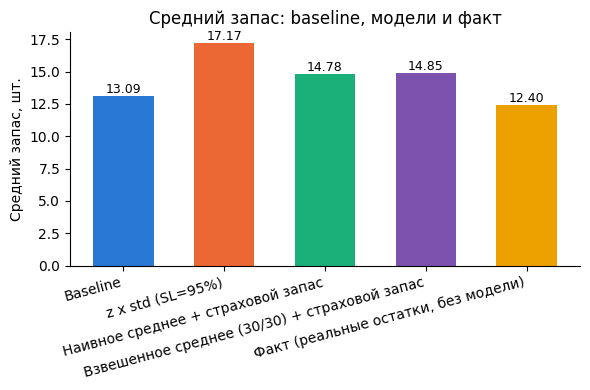

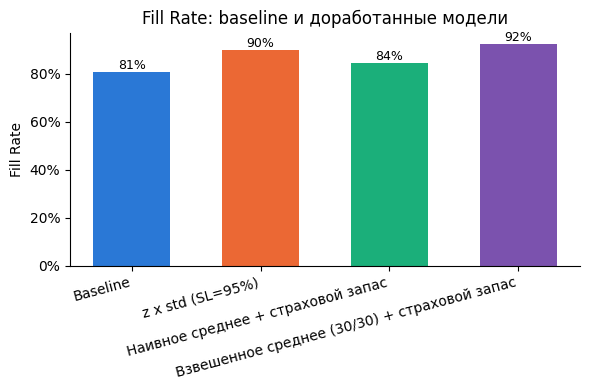

In [55]:
plot_comparison_bars(comparison_df, "avg_inventory", "Средний запас, шт.", "Средний запас: baseline, модели и факт")

# Факт исключаем - его Fill Rate равен 100% тривиально (сравнение факта с самим собой),
# показывать его рядом с реальными результатами моделей было бы вводящим в заблуждение.
plot_comparison_bars(
    comparison_df, "fill_rate", "Fill Rate", "Fill Rate: baseline и доработанные модели",
    exclude_models=["Факт (реальные остатки, без модели)"], as_percent=True,
)

### Выводы и наблюдения

Все три доработанные модели улучшают baseline (Cycle Service Level 95,2%, Fill Rate 80,6%) на TEST-датах:

| модель | CSL | Fill Rate | средний запас |
|---|---:|---:|---:|
| z × std (SL=95%) | 97,8% | 89,8% | 17,2 шт. (+31% к baseline) |
| Наивное среднее + страховой запас | 96,8% | 84,4% | 14,8 шт. (+13% к baseline) |
| Взвешенное среднее (30/30) + страховой запас | 98,2% | 92,5% | 14,9 шт. (+14% к baseline) |

**Контролируемое сравнение: наивное vs взвешенное среднее, один и тот же буфер в днях.** Это два метода с идентичным механизмом страхового запаса (`+SAFETY_DAYS` дней), отличаются только оценкой среднего спроса. При почти одинаковом среднем запасе (14,8 против 14,9 шт. - разница в пределах шума) взвешенное среднее даёт заметно лучший результат: CSL +1,4 п.п., Fill Rate +8,1 п.п. Более того, по обеим метрикам оно обгоняет и z × std, при этом используя на ~13% меньше запаса (14,9 против 17,2 шт.).

**Прежде чем доверять этому результату, проверил, за счёт чего он получается** - слишком хороший результат сам по себе повод для проверки, а не для того, чтобы сразу его принять (та же логика, что привела к отказу от поправки на censored demand в начале раздела). Оказалось: у 328 из 600 решений (54,7%) взвешенное среднее равно нулю - против 60 из 600 (10%) у наивного среднего (проверка - в блоке выше). Причина: окно взвешенного среднего - всего 60 дней, а у сильно прерывистого спроса (85% SKU продают меньше чем в 10% дней, раздел 1) за 60 дней у половины SKU может не найтись ни одной продажи, даже если долгосрочный спрос у них не нулевой.

**Что это значит на практике.** Метод не столько плавно поправляет оценку на тренд, сколько жёстко отключает страховой запас примерно у половины ассортимента - у тех SKU, что не продавались в последние 60 дней. На TEST-датах это сработало в плюс, скорее всего потому что "продавался недавно" слабо коррелирует с "продастся в ближайшие 12-15 дней" (короткая память прерывистого спроса) - модель отчасти эксплуатирует эту корреляцию, а не аккуратно компенсирует найденный тренд. Для SKU с реальным, но редким спросом (раз в 90-120 дней) это риск: конкретному SKU может не повезти с окном, и защита обнулится ровно тогда, когда она нужна - просто на этих TEST-датах не нашлось SKU, где это проявилось бы как дефицит.

**Ограничение проверки, которое стоит держать в уме отдельно.** 3 TEST-даты (27.08, 29.08, 03.09) охватывают всего неделю - у них почти одинаковый набор "кто продавался в последние 60 дней", то есть это не три независимых подтверждения результата, а скорее одна и та же ситуация, увиденная трижды. Более длинный и разнесённый по времени TEST-набор мог бы показать другую картину.

**Итог.** Результат интересный и заслуживает дальнейшего изучения (например, не хардкодить 0 при пустом окне, а подстраховываться наивным средним), но оставляю z × std основной методикой для финального расчёта в разделе 3 - у неё нет этого риска "жёсткого нуля" по конструкции, а взвешенное среднее в текущем виде даёт красивую агрегированную цифру ценой скрытого риска на уровне отдельных SKU, который этот бэктест ещё не может честно измерить.

**Сравнение с фактом.** Средний запас: факт - **12,4 шт.**, baseline - 13,1 (почти совпадает), z × std - 17,2 (на 38% больше факта), взвешенное среднее - 14,9 (на 20% больше факта). Cycle Service Level и Fill Rate у факта равны 100% тривиально (сравнение факта с самим собой, журнала упущенных продаж нет) - не оценка качества реальной системы, поэтому сравнивать с ней имеет смысл только средний запас.

## Чувствительность к уровню сервиса (на TUNE-датах)

Пересчитываем доработанную модель при Service Level 90/95/98% на TUNE-датах - они отделены заранее от TEST (см. разделение на подбор параметров и проверку выше), а не на тех, по которым отчитываемся в сравнении с baseline ниже. Так выбор параметра не подсматривает в данные, на которых его же потом хвалим.

In [56]:
# Baseline на TUNE-датах - точка отсчёта для сравнения чувствительности (не итоговое сравнение).
tune_baseline_decisions = compute_baseline_decisions(tune_dates_df)
sensitivity_rows = [compute_metrics(tune_baseline_decisions, "Baseline (TUNE)")]

# Прогоняем доработанную модель при трёх уровнях сервиса - переиспользуем build_decisions.
for sl in [0.90, 0.95, 0.98]:
    decisions = build_decisions(tune_dates_df, get_S_with_safety_stock, service_level=sl)
    metrics = compute_metrics(decisions, f"SL={sl:.0%} (TUNE)")
    sensitivity_rows.append(metrics)

sensitivity_df = pd.concat(sensitivity_rows, ignore_index=True)
sensitivity_df

,model,cycle_service_level,fill_rate,avg_inventory,max_inventory,total_shortfall,total_excess
0,Baseline (TUNE),0.950,0.879326,15.005,326.0,652.0,10254.0
1,SL=90% (TUNE),0.971,0.937627,17.629,326.0,337.0,12563.0
2,SL=95% (TUNE),0.975,0.948917,18.606,326.0,276.0,13479.0
3,SL=98% (TUNE),0.983,0.959097,19.914,356.0,221.0,14732.0


### Графики чувствительности

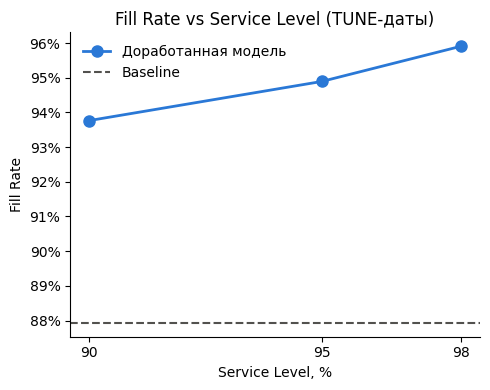

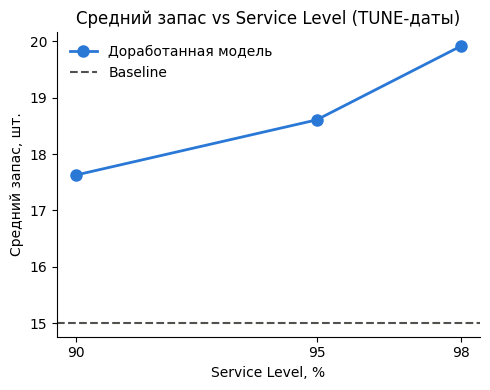

In [57]:
plot_sensitivity_metric(
    sensitivity_df, "fill_rate", "Fill Rate", "Fill Rate vs Service Level (TUNE-даты)", as_percent=True
)
plot_sensitivity_metric(
    sensitivity_df, "avg_inventory", "Средний запас, шт.", "Средний запас vs Service Level (TUNE-даты)"
)

### Выводы по разделу 2

**Чувствительность (на TUNE-датах).** Рост Service Level с 90% до 98% даёт монотонный компромисс: Fill Rate растёт с 93,8% до 95,9%, средний запас - с 17,6 до 19,9 шт.

**Выбор итогового уровня сервиса - 95%.** Задание не фиксирует целевой Service Level числом явно. Отдача от роста запаса на единицу Fill Rate немного замедляется после 95% (с 90% до 95% - плюс 1,1 п.п. Fill Rate на плюс 1,0 шт. запаса; с 95% до 98% - плюс 1,0 п.п. на плюс 1,3 шт.), поэтому 95% выбран как разумная точка баланса, не крайняя ни в одну, ни в другую сторону.

**Разделение периодов.** 5 более ранних дат (TUNE) ушли на подбор Service Level, 3 более поздние (TEST) - на итоговое сравнение с baseline, чтобы не оценивать модель на тех же данных, на которых она настраивалась.

**Про поправку на дефицит.** Пробовал корректировать исторические продажи на днях с нулевым остатком (censored demand), но нашёл случай, где такая поправка стирает реальную крупную продажу и подставляет вместо неё выдуманное маленькое число - подробный пример в блоке выше. Решил так не делать: "наличие и отсутствие товара" из задания учитывается через сам бэктест (`shortfall` - разница между тем, что дала бы наша модель, и тем, что реально продалось), а не через переписывание истории.

**Ограничения методологии бэктеста:**
- Проверка решения идёт по сумме за весь период, без учёта того, что заказ физически появляется только после lead time (см. допущения бэктеста выше). Это может переоценивать сервис у SKU со спросом, смещённым к началу периода. Выбор осознанный: размер сегодняшнего заказа всё равно не может повлиять на дефицит в первые `LeadTimeDays` дней, поэтому разбиение на фазы не изменило бы само решение.
- `InTransit`/`OpenPO` = 0 для всех исторических контрольных дат, потому что исторического журнала поставок физически нет. Метрики бэктеста из-за этого, вероятно, консервативны (для финального расчёта на 19.09.2025, где реальные данные о поставках есть, это уже не допущение, а точный учёт - раздел 3).
- Всего 8 контрольных дат, из них только 3 в итоговом TEST-сравнении - выборка небольшая, метрики раздела 2 стоит воспринимать как направление, а не как точную величину с узким доверительным интервалом.

Аномалии и ограничения самих данных (пропуски, SKU без истории и так далее) зафиксированы в разделе 1 (EDA), здесь их не дублируем.

# Раздел 3. Заказ

## Финальный расчёт на 19.09.2025

Один разовый прогон доработанной модели (раздел 2, дни защиты + страховой запас, Service Level 95%) на реальную дату расчёта. Два отличия от бэктеста:
1. Настоящая позиция запаса берётся из `SKU` (`CurrentStock`), а не историческое приближение.
2. **`InTransit`/`OpenPO` учитываются только если `ExpectedReceiptDate` попадает в protection period.** Поставка, которая придёт позже, физически не может закрыть спрос в этом цикле, поэтому засчитывать её сейчас было бы некорректно.

In [58]:
# protection period на дату расчёта - тот же самый, что уже проверен выше (15 дней).
final_protection_period_days = get_protection_period_days(CALCULATION_DATE)

# S по доработанной модели - дни защиты + страховой запас, на реальной дате расчёта.
final_S = get_S_with_safety_stock(CALCULATION_DATE, final_protection_period_days, SERVICE_LEVEL)

# Горизонт, до которого поставка ещё успевает помочь в этом цикле.
horizon_end = CALCULATION_DATE + pd.Timedelta(days=final_protection_period_days - 1)

# Из всех открытых поставок учитываем только те, что прибудут не позже горизонта.
supply_in_horizon = open_supply_df[open_supply_df["ExpectedReceiptDate"] <= horizon_end]
supply_out_of_horizon = open_supply_df[open_supply_df["ExpectedReceiptDate"] > horizon_end]
supply_in_horizon_by_sku = supply_in_horizon.groupby("SKU")["Qty"].sum()

# Позиция запаса = реальный текущий остаток + только те поставки, что попадают в горизонт.
final_inventory_position = (
    sku_df.set_index("SKU")["CurrentStock"] + supply_in_horizon_by_sku.reindex(sku_df["SKU"]).fillna(0.0)
).rename("inventory_position")

print("Protection period:", final_protection_period_days, "дней, горизонт до", horizon_end.date())
print("Поставок всего:", len(open_supply_df))
print("Поставок в горизонте (учтены):", len(supply_in_horizon))
print("Поставок позже горизонта (не учтены):", len(supply_out_of_horizon), f"({len(supply_out_of_horizon) / len(open_supply_df):.1%})")
final_S.describe()

Protection period: 15 дней, горизонт до 2025-10-03
Поставок всего: 199
Поставок в горизонте (учтены): 140
Поставок позже горизонта (не учтены): 59 (29.6%)


count    200.000000
mean      13.992416
std       35.235550
min        0.000000
25%        0.661324
50%        2.424721
75%        9.232548
max      311.055560
Name: SalesQty, dtype: float64

## RecommendedOrder + пометка для SKU без истории продаж

По условию задания позиции без достаточной истории нельзя просто пропустить, нужно явное решение с комментарием. У нас это 18 SKU, у которых за все 457 дней не было ни одной продажи (найдены в EDA выше). Модель для них возвращает 0 - просто потому что нет данных, чтобы предположить что-то другое, а не потому что спрос низкий, но измеримый.

In [59]:
final_order_df = pd.DataFrame({"SKU": sku_df["SKU"]})
final_order_df = final_order_df.merge(final_S.rename("S"), on="SKU", how="left")
final_order_df = final_order_df.merge(final_inventory_position, on="SKU", how="left")

# Формула не меняется - та же, что и везде в проекте.
gap = final_order_df["S"] - final_order_df["inventory_position"]
final_order_df["RecommendedOrder"] = gap.round().clip(lower=0).astype(int)

# SKU без единой продажи за всю историю - явная пометка, а не молчаливый ноль.
zero_history_skus = set(sku_activity.loc[sku_activity["total_sales"] == 0, "SKU"])
final_order_df["Комментарий"] = final_order_df["SKU"].apply(
    lambda sku: (
        "Нет истории продаж за 457 дней - рекомендация 0 отражает отсутствие данных, "
        "а не подтверждённый нулевой спрос. Требует ручной проверки перед заказом."
    ) if sku in zero_history_skus else ""
)

print("Строк:", len(final_order_df))
print("Все 200 SKU на месте:", set(final_order_df["SKU"]) == set(sku_df["SKU"]))
print("RecommendedOrder целые и неотрицательные:", (final_order_df["RecommendedOrder"] >= 0).all() and final_order_df["RecommendedOrder"].dtype.kind == "i")
print("SKU с пометкой 'нет истории':", (final_order_df["Комментарий"] != "").sum())
print("Суммарный объём заказа:", final_order_df["RecommendedOrder"].sum(), "шт.")

final_order_df.sort_values("RecommendedOrder", ascending=False).head(10)

Строк: 200
Все 200 SKU на месте: True
RecommendedOrder целые и неотрицательные: True
SKU с пометкой 'нет истории': 18
Суммарный объём заказа: 828 шт.


,SKU,S,inventory_position,RecommendedOrder,Комментарий
24,TEST-0025,179.507871,85.0,95,
42,TEST-0043,311.055560,236.0,75,
117,TEST-0118,95.048135,26.0,69,
135,TEST-0136,58.961753,0.0,59,
48,TEST-0049,38.925800,0.0,39,
164,TEST-0165,132.351264,97.0,35,
81,TEST-0082,40.936260,9.0,32,
51,TEST-0052,30.708439,0.0,31,
68,TEST-0069,41.207624,12.0,29,
181,TEST-0182,59.617959,31.0,29,


## Экспорт в RecommendedOrder.xlsx

In [60]:
# Папка output/ уже существует в проекте (с .gitkeep) - собираем путь относительно корня.
output_dir = project_dir / "output"
output_path = output_dir / "RecommendedOrder.xlsx"

# Экспортируем только итоговые колонки, которые нужны по условию задания.
final_order_df[["SKU", "RecommendedOrder", "Комментарий"]].to_excel(output_path, index=False)

print("Сохранено:", output_path)

# Перечитываем сохранённый файл - проверка, что экспорт действительно корректен, а не просто "не упал".
check_df = pd.read_excel(output_path)
print("Строк в сохранённом файле:", len(check_df))
print("Колонки:", list(check_df.columns))

Сохранено: C:\Users\User\Desktop\clode folder\projects_code\тестовое от Генерации\reorder-model\output\RecommendedOrder.xlsx
Строк в сохранённом файле: 200
Колонки: ['SKU', 'RecommendedOrder', 'Комментарий']


### Выводы и итоги проекта

**Финальная рекомендация на 19.09.2025:** 200 SKU, суммарно **828 шт.** к заказу.

**Методика в двух словах:**
- Спрос оценивается по формуле "дни защиты + страховой запас": среднесуточный спрос, умноженный на protection period, плюс `z(Service Level) × эмпирическое std` скользящих сумм спроса за такие периоды. Спрос берётся по фактическим продажам как есть, без попыток угадать недополученный спрос на днях дефицита - такая поправка пробовалась, но искажала факты (подробности в разделе 2), и от неё отказались.
- Protection period = срок поставки (10 дней) плюс интервал до следующего заказа из `OrderCalendar`. Вычисляется, а не хардкодится.
- **Поставки (`InTransit`/`OpenPO`) учитываются только если успевают прийти в защитный период.** Из 199 открытых поставок 59 (29,6%) прибывают позже горизонта и в расчёт не идут.
- Service Level = 95%, выбран по чувствительности (раздел 2) на данных, не участвовавших в итоговой проверке.
- **"Наличие и отсутствие товара"** учитывается через бэктест: дефицитом считается ситуация, когда наша модель дала бы нулевой остаток, а фактические продажи всё равно случились - прямое сравнение с фактом, а не домысел.
- Модель проверена бэктестом на 3 независимых TEST-датах, отдельных от 5 TUNE-дат подбора параметра.
- 18 SKU без истории продаж явно помечены в итоговой таблице, а не скрыты под нулём.

**Результаты бэктеста (TEST-даты).** Доработанная модель против baseline: **Cycle Service Level 95,2% → 97,8%**, **Fill Rate 80,6% → 89,8%**, ценой роста среднего запаса на 31% (13,1 → 17,2 шт.).

**Основные ограничения (полный список - в разделе 2):**
- Бэктест не учитывает точный момент прихода заказа внутри protection period - считает сумму за весь период, а не по фазам. Выбор осознанный, на само решение о размере заказа он не влияет.
- Историю поставок (`InTransit`/`OpenPO`) для бэктеста пришлось принять за 0, потому что исторического журнала физически нет. Для финального расчёта это не проблема - там используются реальные данные `OpenSupply`.
- Всего 8 контрольных дат, из них только 3 - в итоговом TEST-наборе. Выборка небольшая, метрики раздела 2 стоит воспринимать как направление, а не как точную величину.
- 2 SKU (TEST-0040, TEST-0169) имеют длинные провалы в наблюдениях остатка. На финальный расчёт это не влияет, там используется текущий снимок `SKU`, но ограничивает точность их участия в бэктесте.
- Спрос не стационарен во времени - есть тренд и сезонность (раздел 1), а z x std взвешивает всю историю поровну. Пробовал компенсировать это взвешенным средним по недавней истории (раздел 2) - оно даже обгоняет z x std по Cycle Service Level и Fill Rate при меньшем запасе, но ценой того, что почти у половины решений (54,7%) оценка спроса обнуляется из-за короткого окна. Риск для реально редких SKU не подтверждён, но и не исключён на имеющемся TEST-наборе, поэтому z x std остаётся основной методикой.
- Выбросы в продажах и небольшое расхождение `CurrentStock` с последним известным остатком истории найдены и разобраны (раздел 1), но не потребовали правки формулы.

**Направления развития**, если понадобится больше времени: явные модели интермиттентного спроса (Croston/SBA), посуточная симуляция бэктеста вместо суммы за период, доработка взвешенного среднего - подстраховка наивным средним при пустом окне вместо жёсткого нуля, и проверка на более длинном и разнесённом по времени TEST-наборе, экономически обоснованный выбор Service Level через сопоставление стоимости дефицита и хранения (формально это newsvendor-задача - `S* = квантиль(Cu/(Cu+Co))`, но цифр по марже и стоимости хранения в задании нет, поэтому реализация вне рамок текущей версии), расширение TUNE/TEST выборки контрольных дат.